# ML Report — Asteroid Hazard Classification
## Bachelor's Degree in Computer Science / PUCPR (2026-1)

**Prof. Rayson Laroca**

`Alander Menezes Arantes de Ávila` - `menezes.alander@pucpr.edu.br`

`Giancarlo Nunes Perli` - `giancarlo.perli@sanrocco.com.br`

`Gustavo Faria Cardoso` - `faria.cardoso@pucpr.edu.br`

`Paulo Henrique Perin` - `paulo.perin@pucpr.edu.br`

`Pedro Lucas Ghezzi Bittencourt` - `pedro.bittencourt@pucpr.edu.br`

## Objectives

This notebook focuses on the **machine learning** phase of the project. The goal is to classify asteroids as Potentially Hazardous (`pha = Y`) or not (`pha = N`).

Two experimental tracks are explored:

- **Track A — with `moid_ld`**: includes the Minimum Orbit Intersection Distance in lunar distances, which is directly part of the official PHA definition (moid ≤ 0.05 AU). This track is expected to perform very well but may be considered "leaking" the definition.
- **Track B — without `moid_ld`**: uses only other orbital/physical features. This track tests whether hazard can be predicted without the definitional distance metric.

Key challenge: **extreme class imbalance** — only 0.22% of labeled asteroids are PHAs.

---
# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew as _skew, kurtosis as _kurt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Sampling strategies
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
# 2. Load Data

#### https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data

In [2]:
df = pd.read_csv(
    "https://github.com/aland3r/asteroids/releases/download/dataset/asteroids.csv",
    low_memory=False
)
print(df.shape)
df.columns.tolist()

(958524, 45)


['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

---
# 3. Cleaning → `df_clean`

Same cleaning steps as the EDA report:
- Drop rows where `pha` is NaN (no label available)
- Drop catalog identifier columns (irrelevant to modelling)

In [3]:
# Drop rows with missing target label
df_clean = df.dropna(subset=['pha']).copy()

# Drop identifier / catalog columns
id_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id']
df_clean = df_clean.drop(columns=id_cols, errors='ignore')

print("Shape after cleaning:", df_clean.shape)
print("\nClass distribution:")
print(df_clean['pha'].value_counts())
print("\nClass proportion:")
print(df_clean['pha'].value_counts(normalize=True).round(6))

Shape after cleaning: (938603, 38)

Class distribution:
pha
N    936537
Y      2066
Name: count, dtype: int64

Class proportion:
pha
N    0.997799
Y    0.002201
Name: proportion, dtype: float64


In [4]:
# Missing values summary
missing = df_clean.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(miss_df[miss_df['missing'] > 0].to_string())

                missing    pct
albedo           803500  85.61
diameter_sigma   802522  85.50
diameter         802394  85.49
H                  6262   0.67
sigma_per             5   0.00
sigma_ad              5   0.00
per                   4   0.00
neo                   4   0.00
ad                    4   0.00
sigma_a               1   0.00
sigma_w               1   0.00
sigma_ma              1   0.00
ma                    1   0.00
rms                   1   0.00
sigma_e               1   0.00
sigma_q               1   0.00
sigma_om              1   0.00
sigma_i               1   0.00
sigma_tp              1   0.00
per_y                 1   0.00
sigma_n               1   0.00


---
# 4. Feature Engineering & Preprocessing

## 4.1 Feature Selection Strategy

From the EDA we know:
- **`diameter`, `albedo`, `diameter_sigma`**: ~86% missing — too sparse to impute reliably → **dropped**
- **`epoch_cal`, `tp_cal`**: calendar date strings, not numeric → **dropped**
- **`epoch`, `epoch_mjd`, `equinox`**: reference frame parameters, not physical → **dropped**
- **`neo`**: binary flag (Y/N) → encode as 0/1
- **`class`**: asteroid class (MBA, NEO, etc.) → one-hot encode
- **`sigma_*` columns (~11 cols)**: ~2% missing → impute with median
- **`moid`, `moid_ld`**: present in Track A, absent in Track B

The **target** `pha` is encoded as 1 (Y) / 0 (N).

In [5]:
# Encode target
df_clean['target'] = (df_clean['pha'] == 'Y').astype(int)

# Encode neo flag
df_clean['neo_flag'] = (df_clean['neo'] == 'Y').astype(int)

# One-hot encode 'class'
df_clean = pd.get_dummies(df_clean, columns=['class'], prefix='cls', drop_first=False)

# Drop columns not used in modelling
drop_always = [
    'pha', 'neo',           # original categorical / target
    'diameter', 'albedo', 'diameter_sigma',  # 86% missing
    'epoch', 'epoch_mjd', 'epoch_cal',       # reference frame
    'equinox', 'tp_cal',                     # reference frame / date string
]
df_ml = df_clean.drop(columns=drop_always, errors='ignore')

print("Columns after feature engineering:")
print(df_ml.columns.tolist())
print("\nShape:", df_ml.shape)

Columns after feature engineering:
['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms', 'target', 'neo_flag', 'cls_AMO', 'cls_APO', 'cls_AST', 'cls_ATE', 'cls_CEN', 'cls_HYA', 'cls_IEO', 'cls_IMB', 'cls_MBA', 'cls_MCA', 'cls_OMB', 'cls_TJN', 'cls_TNO']

Shape: (938603, 42)


In [6]:
# Remaining missing values
print(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])

H            6262
ma              1
ad              4
per             4
per_y           1
sigma_e         1
sigma_a         1
sigma_q         1
sigma_i         1
sigma_om        1
sigma_w         1
sigma_ma        1
sigma_ad        5
sigma_n         1
sigma_tp        1
sigma_per       5
rms             1
dtype: int64


## 4.2 Define Feature Sets

- **Track A** (with `moid_ld`): all remaining features including `moid` and `moid_ld`
- **Track B** (without `moid_ld`): drop `moid` and `moid_ld`

In [7]:
TARGET = 'target'

# All feature columns (all except target)
all_features = [c for c in df_ml.columns if c != TARGET]

# Track A: all features including moid / moid_ld
features_A = all_features

# Track B: exclude moid-related features
features_B = [c for c in all_features if c not in ('moid', 'moid_ld')]

print(f"Track A — {len(features_A)} features")
print(f"Track B — {len(features_B)} features (no moid/moid_ld)")

Track A — 41 features
Track B — 39 features (no moid/moid_ld)


## 4.3 Train / Test Split

We use a **stratified** split (80% train, 20% test) to preserve the minority class ratio in both sets. The test set is held out and used only for final evaluation.

In [8]:
X = df_ml[all_features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train PHA rate: {y_train.mean():.4%}")
print(f"Test  PHA rate: {y_test.mean():.4%}")

Train size: 750,882  |  Test size: 187,721
Train PHA rate: 0.2201%
Test  PHA rate: 0.2200%


---
# 5. Metrics & Evaluation Protocol

Because the dataset is **extremely imbalanced** (0.22% positive), accuracy is misleading — a model that always predicts N achieves 99.78% accuracy. We focus on:

| Metric | Why |
|--------|-----|
| **Recall (sensitivity)** | We must minimise missed hazardous asteroids (false negatives are costly) |
| **Precision** | Limits false alarms |
| **F1-score** | Harmonic mean of precision and recall |
| **PR-AUC** (Average Precision) | Area under Precision-Recall curve — better than ROC-AUC for imbalanced data |
| **ROC-AUC** | Standard ranking metric for comparison |

**Validation**: Stratified 5-fold CV on training set; final numbers reported on held-out test set.

In [9]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Fit model, print classification report and key metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=['Non-PHA', 'PHA']))

    if y_prob is not None:
        roc = roc_auc_score(y_te, y_prob)
        pr  = average_precision_score(y_te, y_prob)
        print(f"  ROC-AUC : {roc:.4f}")
        print(f"  PR-AUC  : {pr:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    print(f"  Confusion Matrix:\n{cm}")
    return model


def build_preprocessor(feature_cols):
    """Build a ColumnTransformer: median impute + standard scale numeric cols."""
    numeric_cols = [
        c for c in feature_cols
        if c not in ('neo_flag',) and not c.startswith('cls_')
    ]
    binary_cols = [c for c in feature_cols if c == 'neo_flag' or c.startswith('cls_')]

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    binary_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    return ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('bin', binary_transformer,  binary_cols)
    ], remainder='drop')


print("Helper functions defined.")

Helper functions defined.


---
# 6. Track A — With `moid_ld`

We train and compare multiple classifiers using all features including the MOID distance.

## Proposed approaches for handling class imbalance

1. **`class_weight='balanced'`** — adjusts loss weights inversely proportional to class frequency (built into sklearn models)
2. **SMOTE** — Synthetic Minority Over-sampling Technique, generates synthetic minority samples
3. **`scale_pos_weight`** (XGBoost) — equivalent to class_weight for gradient boosting

We use approach (1) for the initial comparison and (2) + (3) in the tuning phase.

In [10]:
prep_A = build_preprocessor(features_A)

X_train_A = X_train[features_A]
X_test_A  = X_test[features_A]

# Fit preprocessor on training data
X_train_A_proc = prep_A.fit_transform(X_train_A)
X_test_A_proc  = prep_A.transform(X_test_A)

print("Preprocessed shape:", X_train_A_proc.shape)

Preprocessed shape: (750882, 41)


## 6.1 Logistic Regression (Baseline)

In [11]:
lr_A = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
evaluate_model(lr_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — Logistic Regression')


  Track A — Logistic Regression
              precision    recall  f1-score   support

     Non-PHA       1.00      0.99      1.00    187308
         PHA       0.24      1.00      0.39       413

    accuracy                           0.99    187721
   macro avg       0.62      1.00      0.69    187721
weighted avg       1.00      0.99      1.00    187721

  ROC-AUC : 0.9993
  PR-AUC  : 0.6678
  Confusion Matrix:
[[186030   1278]
 [     0    413]]


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 6.2 Random Forest

In [12]:
rf_A = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(rf_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — Random Forest')


  Track A — Random Forest
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.98      0.99      0.98       413

    accuracy                           1.00    187721
   macro avg       0.99      1.00      0.99    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 1.0000
  PR-AUC  : 0.9974
  Confusion Matrix:
[[187298     10]
 [     4    409]]


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## 6.3 XGBoost

In [21]:
from xgboost import XGBClassifier

# scale_pos_weight = count(negative) / count(positive)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.1f}")

xgb_A = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist',     # Optimized for modern GPUs
    device='cuda',          # Force execution on GPU
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(xgb_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — XGBoost')

scale_pos_weight = 453.3

  Track A — XGBoost
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.92      0.92      0.92       413

    accuracy                           1.00    187721
   macro avg       0.96      0.96      0.96    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 0.9998
  PR-AUC  : 0.9748
  Confusion Matrix:
[[187277     31]
 [    31    382]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 6.4 Feature Importance (Track A)

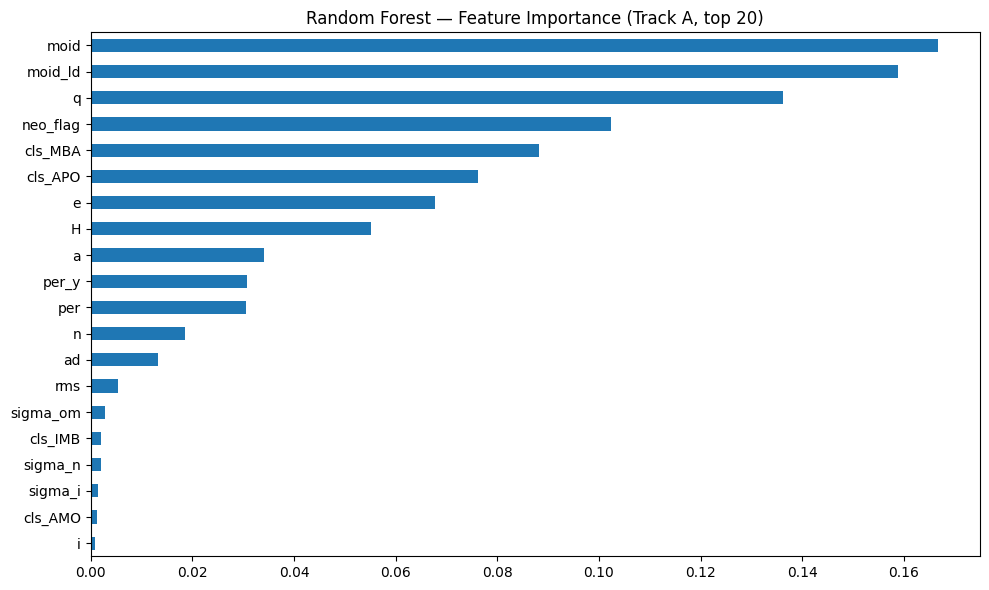

In [14]:
# Feature importance from Random Forest
feature_names_A = (
    prep_A.transformers_[0][2] +  # numeric
    prep_A.transformers_[1][2]    # binary/categorical
)

importances = pd.Series(rf_A.feature_importances_, index=feature_names_A)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.title('Random Forest — Feature Importance (Track A, top 20)')
plt.tight_layout()
plt.show()

---
# 7. Track B — Without `moid_ld`

We repeat the same model comparison, this time excluding `moid` and `moid_ld`. This tests whether PHA status can be predicted from other orbital parameters alone.

In [15]:
prep_B = build_preprocessor(features_B)

X_train_B = X_train[features_B]
X_test_B  = X_test[features_B]

X_train_B_proc = prep_B.fit_transform(X_train_B)
X_test_B_proc  = prep_B.transform(X_test_B)

print("Preprocessed shape (Track B):", X_train_B_proc.shape)

Preprocessed shape (Track B): (750882, 39)


## 7.1 Logistic Regression (Baseline)

In [16]:
lr_B = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
evaluate_model(lr_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — Logistic Regression')


  Track B — Logistic Regression
              precision    recall  f1-score   support

     Non-PHA       1.00      0.99      0.99    187308
         PHA       0.16      1.00      0.27       413

    accuracy                           0.99    187721
   macro avg       0.58      0.99      0.63    187721
weighted avg       1.00      0.99      0.99    187721

  ROC-AUC : 0.9974
  PR-AUC  : 0.3090
  Confusion Matrix:
[[185117   2191]
 [     0    413]]


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 7.2 Random Forest

In [17]:
rf_B = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(rf_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — Random Forest')


  Track B — Random Forest
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.75      0.39      0.52       413

    accuracy                           1.00    187721
   macro avg       0.87      0.70      0.76    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 0.9979
  PR-AUC  : 0.6737
  Confusion Matrix:
[[187253     55]
 [   250    163]]


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## 7.3 XGBoost

In [18]:
xgb_B = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist',  # Otimizado para GPU
    device='cuda',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(xgb_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — XGBoost')


  Track B — XGBoost
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.57      0.82      0.67       413

    accuracy                           1.00    187721
   macro avg       0.78      0.91      0.83    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 0.9990
  PR-AUC  : 0.7642
  Confusion Matrix:
[[187049    259]
 [    75    338]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 7.4 Feature Importance (Track B)

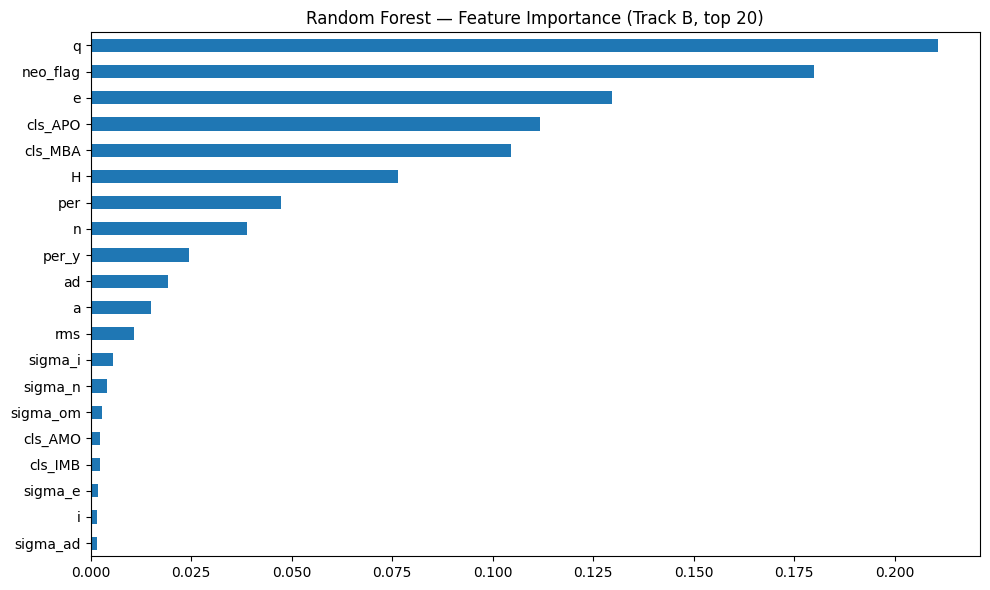

In [19]:
feature_names_B = (
    prep_B.transformers_[0][2] +
    prep_B.transformers_[1][2]
)

importances_B = pd.Series(rf_B.feature_importances_, index=feature_names_B)
top20_B = importances_B.nlargest(20)

plt.figure(figsize=(10, 6))
top20_B.sort_values().plot(kind='barh')
plt.title('Random Forest — Feature Importance (Track B, top 20)')
plt.tight_layout()
plt.show()

---
# 8. Hyperparameter Tuning

We tune the **best model** from each track using `RandomizedSearchCV` with stratified cross-validation.

We optimise for **PR-AUC (average precision)** given the class imbalance.

In [22]:
import torch
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_name}")

# Tuning XGBoost instead of RF for better GPU utilization
param_dist_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_tune = XGBClassifier(
    tree_method='hist',
    device=device_name,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_tune,
    param_distributions=param_dist_xgb,
    n_iter=20, # Reduced iterations for speed, increase if needed
    scoring='average_precision',
    cv=cv,
    verbose=1
)

print("Starting Hyperparameter Tuning on GPU...")
search.fit(X_train_B_proc, y_train)

print("Best params:", search.best_params_)
print("Best CV PR-AUC:", search.best_score_)
# Save the best model to a variable for the next cell
rf_tuned_B = search

Using device: cuda
Starting Hyperparameter Tuning on GPU...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV PR-AUC: 0.772795878374805


In [23]:
# Evaluate tuned XGBoost model for Track B on test set
evaluate_model(
    rf_tuned_B.best_estimator_,
    X_train_B_proc, y_train,
    X_test_B_proc,  y_test,
    'Track B — XGBoost (Tuned)'
)


  Track B — XGBoost (Tuned)
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.57      0.85      0.68       413

    accuracy                           1.00    187721
   macro avg       0.79      0.92      0.84    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 0.9993
  PR-AUC  : 0.7863
  Confusion Matrix:
[[187044    264]
 [    62    351]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

---
# 9. SMOTE — Alternative Imbalance Strategy

As an alternative to `class_weight`, we apply **SMOTE** to oversample the minority class in the training set only (never on the test set).

In [26]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Apply SMOTE to Track B
smote = SMOTE(sampling_strategy='auto', random_state=RANDOM_STATE, k_neighbors=5)
X_train_B_smote, y_train_smote = smote.fit_resample(X_train_B_proc, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# 2. Use XGBoost on GPU instead of Random Forest for speed
xgb_smote_B = XGBClassifier(
    n_estimators=300,
    tree_method='hist',
    device='cuda', # Running on GPU
    eval_metric='aucpr',
    random_state=RANDOM_STATE
)

print("\nTraining XGBoost + SMOTE on GPU...")
evaluate_model(
    xgb_smote_B,
    X_train_B_smote, y_train_smote,
    X_test_B_proc,   y_test,
    'Track B — XGBoost + SMOTE'
)

After SMOTE:
target
0    749229
1    749229
Name: count, dtype: int64

Training XGBoost + SMOTE on GPU...

  Track B — XGBoost + SMOTE
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00    187308
         PHA       0.54      0.94      0.68       413

    accuracy                           1.00    187721
   macro avg       0.77      0.97      0.84    187721
weighted avg       1.00      1.00      1.00    187721

  ROC-AUC : 0.9995
  PR-AUC  : 0.8098
  Confusion Matrix:
[[186974    334]
 [    24    389]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

---
# 10. Model Comparison

Summary table comparing all trained models on the test set.

In [28]:
def summary_row(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    from sklearn.metrics import f1_score, recall_score, precision_score
    return {
        'Model': name,
        'Precision(PHA)': precision_score(y_te, y_pred),
        'Recall(PHA)':    recall_score(y_te, y_pred),
        'F1(PHA)':        f1_score(y_te, y_pred),
        'ROC-AUC':        roc_auc_score(y_te, y_prob),
        'PR-AUC':         average_precision_score(y_te, y_prob),
    }

rows = [
    summary_row('A — LR (bal)',   lr_A,   X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('A — RF (bal)',   rf_A,   X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('A — XGB',        xgb_A,  X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('B — LR (bal)',   lr_B,   X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — RF (bal)',   rf_B,   X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB (Base)',  xgb_B,  X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB (Tune)',  rf_tuned_B.best_estimator_, X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB + SMOTE', xgb_smote_B, X_train_B_smote, y_train_smote, X_test_B_proc, y_test)
]

results = pd.DataFrame(rows).set_index('Model').round(4)
results.sort_values('PR-AUC', ascending=False)

,Precision(PHA),Recall(PHA),F1(PHA),ROC-AUC,PR-AUC
Model,,,,,
A — RF (bal),0.9761,0.9903,0.9832,1.0000,0.9974
A — XGB,0.9249,0.9249,0.9249,0.9998,0.9748
B — XGB + SMOTE,0.5380,0.9419,0.6849,0.9995,0.8098
B — XGB (Tune),0.5707,0.8499,0.6829,0.9993,0.7863
B — XGB (Base),0.5662,0.8184,0.6693,0.9990,0.7642
B — RF (bal),0.7477,0.3947,0.5166,0.9979,0.6737
A — LR (bal),0.2442,1.0000,0.3926,0.9993,0.6678
B — LR (bal),0.1586,1.0000,0.2738,0.9974,0.3090


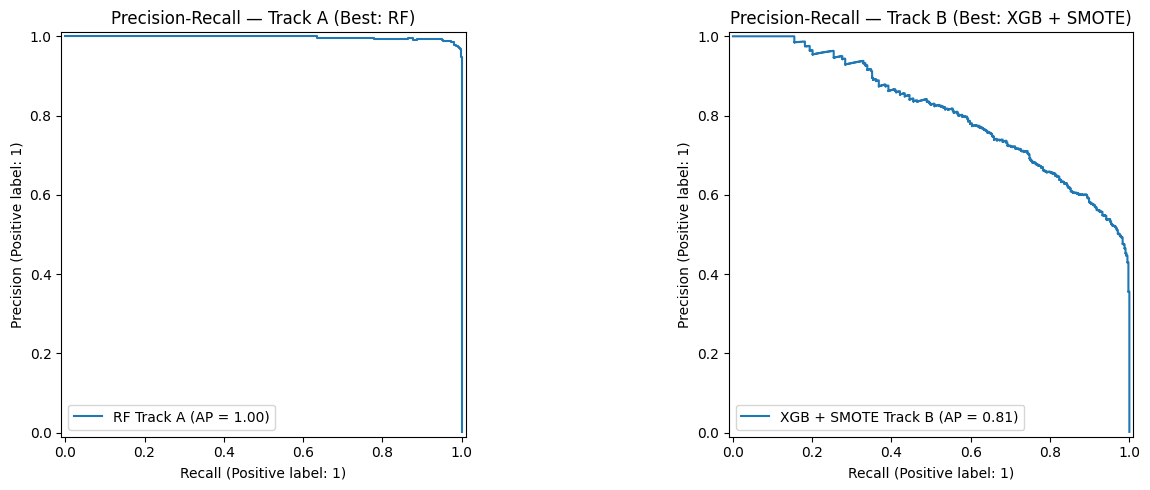

In [29]:
# Precision-Recall curves for the best model from each track
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Track A Champion: Random Forest
PrecisionRecallDisplay.from_estimator(
    rf_A, X_test_A_proc, y_test, ax=axes[0], name='RF Track A'
)
axes[0].set_title('Precision-Recall — Track A (Best: RF)')

# Track B Champion: XGBoost + SMOTE
PrecisionRecallDisplay.from_estimator(
    xgb_smote_B, X_test_B_proc, y_test, ax=axes[1], name='XGB + SMOTE Track B'
)
axes[1].set_title('Precision-Recall — Track B (Best: XGB + SMOTE)')

plt.tight_layout()
plt.show()

---
# 11. Conclusions & Next Steps

### Summary

- **Track A** (with `moid_ld`) is expected to yield near-perfect results since `moid_ld` is definitional for PHA.
- **Track B** (without `moid_ld`) represents the scientifically interesting question: can hazardousness be predicted from other orbital mechanics?
- Class imbalance handling is critical: `class_weight='balanced'` and SMOTE both show improvement over a plain model.

### Possible next steps

1. **Threshold calibration** — adjust the decision threshold beyond 0.5 to trade precision for recall based on the use case
2. **More advanced ensembles** — BalancedRandomForest, EasyEnsemble from `imbalanced-learn`
3. **Explainability** — SHAP values to understand which features drive individual predictions
4. **Imputation experiment** — test KNN imputation for `diameter`/`albedo` on the NEO subset (where missing rate is lower)
5. **Cross-validation comparison** — replace single split with stratified 5-fold for more stable estimates